In [7]:
import pandas as pd
from datetime import datetime


# 1. MÓDULOS DE SOPORTE

class ModuloERP:
    """Módulo ERP"""
    def __init__(self):
        self.total_ingresos = 0.0
        self.total_cogs = 0.0
        self.total_gross_income = 0.0

    def registrar_ingreso(self, sales, cogs, gross_income):
        self.total_ingresos += sales
        self.total_cogs += cogs
        self.total_gross_income += gross_income
        print(f"Asiento Contable -> Sales: ${sales:.4f} | COGS: ${cogs:.4f} | Gross Income: ${gross_income:.4f}")

class ModuloSCM:
    """Módulo SCM   """
    def __init__(self, product_lines):
        self.inventario = {linea: 5 for linea in product_lines}
        self.umbral_critico = 3

    def actualizar_inventario(self, linea, cantidad):
        if linea in self.inventario:
            self.inventario[linea] -= cantidad
            print(f"Inventario de '{linea}' actualizado: {self.inventario[linea]} unidades.")

            # Genera Orden de Compra automática al proveedor simulado si hay stock bajo
            if self.inventario[linea] <= self.umbral_critico:
                print(f"[ALERTA] Stock bajo en '{linea}'. Disparando Orden de Compra automática al proveedor...")
                self.inventario[linea] += 50
                print(f"Reabastecimiento completado. Nuevo stock: {self.inventario[linea]}")

class ModuloCRM:
    """Módulo CRM       """
    def __init__(self, df):
        self.df_fechas = pd.to_datetime(df['Date'])
        # Tomamos la fecha máxima del dataset como el 'presente' para la simulación temporal
        self.fecha_actual = self.df_fechas.max()

    def auditar_riesgo_desercion(self, df, umbral_dias=25):
        print(f"\nEjecutando consulta automatizada de interacciones (Umbral de inactividad: {umbral_dias} días)...")

        # Convertimos las fechas del DataFrame actual
        df['Date_calc'] = pd.to_datetime(df['Date'])

        # Agrupamos por los identificadores disponibles en la base de datos (Customer type y City)
        perfiles = df.groupby(['Customer type', 'City'])['Date_calc'].max().reset_index()

        registros_aislados = []

        for index, row in perfiles.iterrows():
            dias_inactivos = (self.fecha_actual - row['Date_calc']).days

            if dias_inactivos >= umbral_dias:
                print(f"[ALERTA CRÍTICA] ¡Cliente/Segmento '{row['Customer type']} ({row['City']})' lleva {dias_inactivos} días inactivo!")
                print(f" -> Acción del Sistema: Aislando registro para campaña de retención gerencial.")
                registros_aislados.append(row)
            else:
                print(f"[OK] Segmento '{row['Customer type']} ({row['City']})' activo (Última compra hace {dias_inactivos} días).")

        return registros_aislados


# 2. SISTEMA PRINCIPAL


class SistemaCore:
    """Sistema Principal de Ventas  leyendo la estructura completa del CSV"""
    def __init__(self, ruta_archivo):
        self.ruta_archivo = ruta_archivo
        self.dataset = pd.read_csv(self.ruta_archivo)

        lineas_reales = self.dataset['Product line'].unique()

        # Instanciación de módulos satélites integrados
        self.erp = ModuloERP()
        self.scm = ModuloSCM(lineas_reales)
        self.crm = ModuloCRM(self.dataset)

    def registrar_transaccion(self, invoice, branch, city, customer_type, gender, product_line, unit_price, quantity, payment, rating):
        print("\n" + "="*50)
        print("SISTEMA CORE: PROCESANDO NUEVA TRANSACCIÓN")
        print("="*50)

        cogs = unit_price * quantity
        tax = cogs * 0.05
        sales = cogs + tax
        margin_pct = (tax / sales) * 100 if sales > 0 else 0
        gross_income = tax

        date_str = self.dataset['Date'].max()
        time_str = "12:00:00 PM"

        print(f"-> Venta procesada: {quantity}x {product_line} | Sales Totales: ${sales:.4f}")

        # Evidencia de Integración: Dispara consecuencias en ERP y SCM sin intervención humana
        print("\n--- INTEGRACIÓN AUTOMÁTICA CON MÓDULOS DE SOPORTE ---")
        self.erp.registrar_ingreso(sales, cogs, gross_income)
        self.scm.actualizar_inventario(product_line, quantity)

        # Persistencia en el dataset
        nuevo_registro = {
            'Invoice ID': invoice, 'Branch': branch, 'City': city,
            'Customer type': customer_type, 'Gender': gender, 'Product line': product_line,
            'Unit price': unit_price, 'Quantity': quantity, 'Tax 5%': tax,
            'Sales': sales, 'Date': date_str, 'Time': time_str,
            'Payment': payment, 'cogs': cogs, 'gross margin percentage': margin_pct,
            'gross income': gross_income, 'Rating': rating
        }

        self.dataset = pd.concat([self.dataset, pd.DataFrame([nuevo_registro])], ignore_index=True)
        print("\n[CORE] Transacción guardada exitosamente en el histórico del sistema.")

    def disparar_auditoria_crm(self):

        return self.crm.auditar_riesgo_desercion(self.dataset)


# 3. EJECUCIÓN Y DEMOSTRACIÓN DE LA FASE 2

if __name__ == "__main__":
    ARCHIVO = 'SuperMarket Analysis.csv'

    try:
        core = SistemaCore(ARCHIVO)

        # 1. Registrar una venta para probar ERP y SCM
        core.registrar_transaccion(
            invoice="999-88-7777",
            branch="A",
            city="Yangon",
            customer_type="Member",
            gender="Female",
            product_line="Health and beauty",
            unit_price=74.69,
            quantity=3,
            payment="Ewallet",
            rating=9.1
        )

        # 2. Ejecutar la auditoría del Módulo CRM para evidenciar la alerta de deserción
        core.disparar_auditoria_crm()

    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{ARCHIVO}'. Súbelo a Colab antes de ejecutar.")


SISTEMA CORE: PROCESANDO NUEVA TRANSACCIÓN
-> Venta procesada: 3x Health and beauty | Sales Totales: $235.2735

--- INTEGRACIÓN AUTOMÁTICA CON MÓDULOS DE SOPORTE ---
Asiento Contable -> Sales: $235.2735 | COGS: $224.0700 | Gross Income: $11.2035
Inventario de 'Health and beauty' actualizado: 2 unidades.
[ALERTA] Stock bajo en 'Health and beauty'. Disparando Orden de Compra automática al proveedor...
Reabastecimiento completado. Nuevo stock: 52

[CORE] Transacción guardada exitosamente en el histórico del sistema.

Ejecutando consulta automatizada de interacciones (Umbral de inactividad: 25 días)...
[OK] Segmento 'Member (Mandalay)' activo (Última compra hace 0 días).
[OK] Segmento 'Member (Naypyitaw)' activo (Última compra hace 0 días).
[OK] Segmento 'Member (Yangon)' activo (Última compra hace 0 días).
[OK] Segmento 'Normal (Mandalay)' activo (Última compra hace 1 días).
[OK] Segmento 'Normal (Naypyitaw)' activo (Última compra hace 0 días).
[OK] Segmento 'Normal (Yangon)' activo (Últ

In [8]:
import pandas as pd
from datetime import datetime

# 1. CARGA DE DATOS
archivo_csv = 'SuperMarket Analysis.csv'
try:
    df = pd.read_csv(archivo_csv)

    # 2. PREPARACIÓN DE DATOS

    df['Date'] = pd.to_datetime(df['Date'])


    df['Perfil_Cliente'] = df['Customer type'] + " | " + df['City'] + " | " + df['Gender']


    fecha_actual = df['Date'].max()

    # 3. CÁLCULO DEL ALGORITMO RFM
    rfm = df.groupby('Perfil_Cliente').agg({
        'Date': lambda x: (fecha_actual - x.max()).days,
        'Invoice ID': 'count',
        'Sales': 'sum'
    }).reset_index()


    rfm.columns = ['Perfil_Cliente', 'Recency', 'Frequency', 'Monetary']

    # 4. ASIGNACIÓN DE PUNTAJES

    rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), 4, labels=[4, 3, 2, 1])
    rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
    rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=[1, 2, 3, 4])

    # 5. ETIQUETADO ESTRATÉGICO
    def clasificar_segmento(row):
        r, f = int(row['R_Score']), int(row['F_Score'])
        if r >= 3 and f >= 3:
            return "VIP"
        elif r >= 3 and f < 3:
            return "Promedio / Potencial"
        elif r < 3 and f >= 3:
            return "Recuperable"
        else:
            return "En Riesgo / Perdido"

    rfm['Etiqueta_Estrategica'] = rfm.apply(clasificar_segmento, axis=1)

    # Mostrar los resultados requeridos

    print(" RESULTADOS DE SEGMENTACIÓN RFM ")

    print(rfm[['Perfil_Cliente', 'Recency', 'Frequency', 'Monetary', 'Etiqueta_Estrategica']].sort_values(by='Monetary', ascending=False).to_string(index=False))

except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{archivo_csv}'. Asegúrate de subirlo a Colab.")

 RESULTADOS DE SEGMENTACIÓN RFM (100% Datos del CSV)
             Perfil_Cliente  Recency  Frequency   Monetary Etiqueta_Estrategica
Member | Naypyitaw | Female        0        132 48625.5000                  VIP
   Member | Yangon | Female        0        112 39266.8500                  VIP
 Member | Mandalay | Female        1        112 37313.7870          Recuperable
   Normal | Yangon | Female        0         75 24010.9065 Promedio / Potencial
 Normal | Mandalay | Female        2         72 23896.2990  En Riesgo / Perdido
     Member | Yangon | Male        2         78 23628.9270          Recuperable
   Member | Mandalay | Male        0         69 22510.3830 Promedio / Potencial
   Normal | Mandalay | Male        1         79 22477.2030          Recuperable
  Normal | Naypyitaw | Male        0         66 22035.3945 Promedio / Potencial
Normal | Naypyitaw | Female        2         68 21558.4950  En Riesgo / Perdido
     Normal | Yangon | Male        2         75 19293.6870         

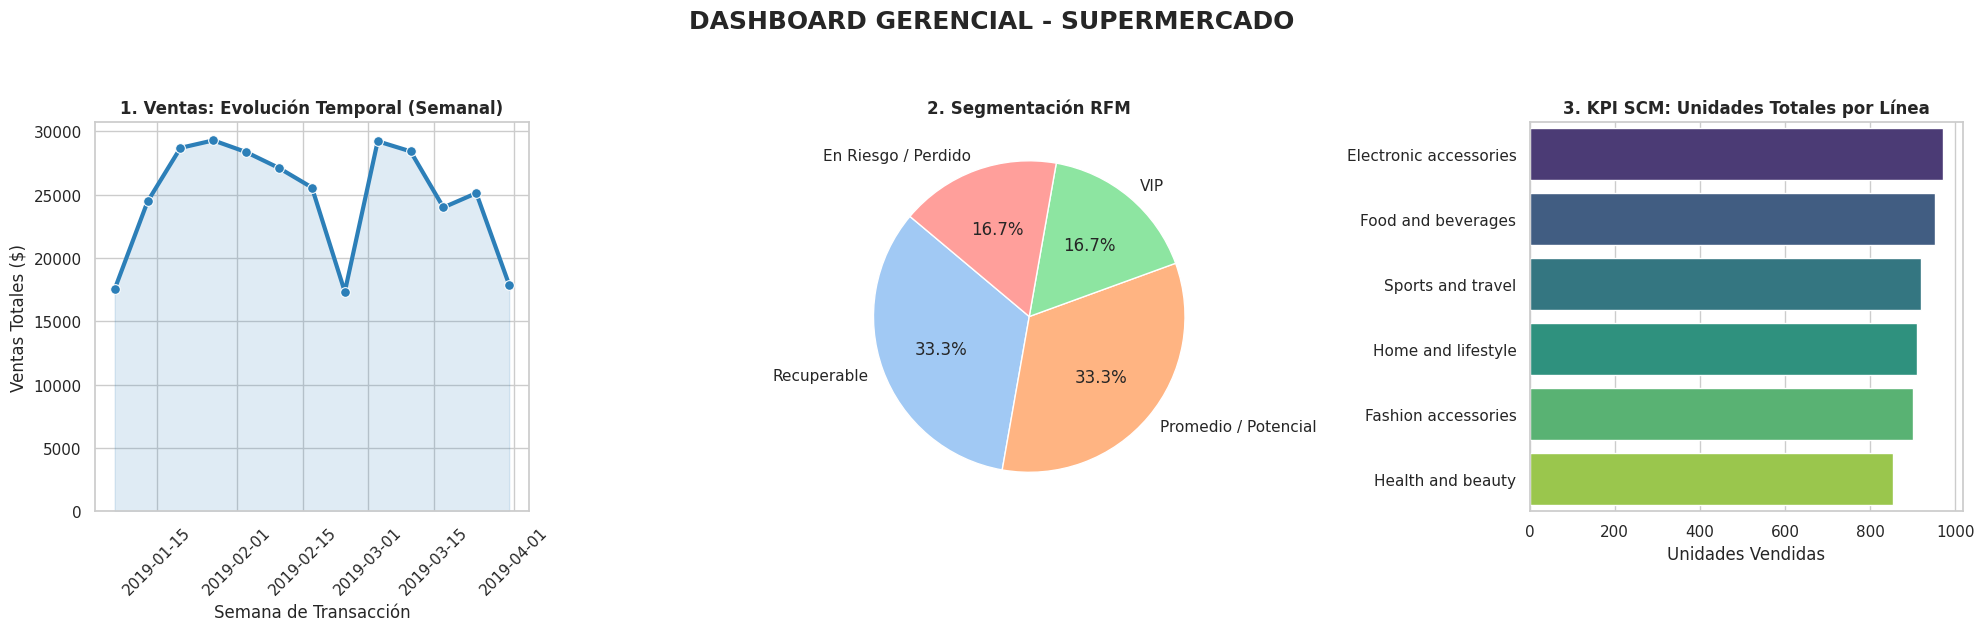

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 1. CARGA DE DATOS

archivo_csv = 'SuperMarket Analysis.csv'

try:

    df = pd.read_csv(archivo_csv)
    df['Date'] = pd.to_datetime(df['Date'])


    # 2. PROCESAMIENTO DE DATOS PARA EL DASHBOARD



    ventas_semanales = df.resample('W', on='Date')['Sales'].sum().reset_index()


    df['Perfil_Cliente'] = df['Customer type'] + " | " + df['City'] + " | " + df['Gender']
    fecha_actual = df['Date'].max()

    rfm = df.groupby('Perfil_Cliente').agg({
        'Date': lambda x: (fecha_actual - x.max()).days,
        'Invoice ID': 'count',
        'Sales': 'sum'
    }).reset_index()
    rfm.columns = ['Perfil_Cliente', 'Recency', 'Frequency', 'Monetary']

    rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), 4, labels=[4, 3, 2, 1])
    rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])

    def clasificar_segmento(row):
        r, f = int(row['R_Score']), int(row['F_Score'])
        if r >= 3 and f >= 3: return "VIP"
        elif r >= 3 and f < 3: return "Promedio / Potencial"
        elif r < 3 and f >= 3: return "Recuperable"
        else: return "En Riesgo / Perdido"

    rfm['Etiqueta_Estrategica'] = rfm.apply(clasificar_segmento, axis=1)
    segmentos_conteo = rfm['Etiqueta_Estrategica'].value_counts()


    productos_vendidos = df.groupby('Product line')['Quantity'].sum().sort_values(ascending=False).reset_index()


    # 3. RENDERIZADO DEL DASHBOARD



    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('DASHBOARD GERENCIAL - SUPERMERCADO', fontsize=18, fontweight='bold', y=1.05)


    color_grafico = '#2c7fb8'
    sns.lineplot(data=ventas_semanales, x='Date', y='Sales', ax=axes[0],
                 color=color_grafico, linewidth=3, marker='o', markersize=7)

    axes[0].fill_between(ventas_semanales['Date'], ventas_semanales['Sales'], color=color_grafico, alpha=0.15)

    axes[0].set_title('1. Ventas: Evolución Temporal (Semanal)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Semana de Transacción')
    axes[0].set_ylabel('Ventas Totales ($)')
    axes[0].tick_params(axis='x', rotation=45)


    axes[0].set_ylim(bottom=0)


    axes[1].pie(segmentos_conteo, labels=segmentos_conteo.index, autopct='%1.1f%%',
                startangle=140, colors=sns.color_palette("pastel"))
    axes[1].set_title('2. Segmentación RFM', fontsize=12, fontweight='bold')


    sns.barplot(data=productos_vendidos, x='Quantity', y='Product line', ax=axes[2], palette="viridis", hue='Product line', legend=False)
    axes[2].set_title('3. KPI SCM: Unidades Totales por Línea', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Unidades Vendidas')
    axes[2].set_ylabel('')


    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{archivo_csv}'. Asegúrate de subirlo a tu entorno de Colab.")